In [1]:
import os, sys
import numpy as np
import torch
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sys.path.append('../')
from STARMap.utils import *
from STARMap.preprocess import *
from STARMap.STARMap_pyG import Train_STARMap

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

os.environ.setdefault('LANG', 'en_US.UTF-8')
os.environ.setdefault('LC_ALL', 'en_US.UTF-8')

r_home = detect_r_home()
mclust_ready = check_mclust(install_if_missing=False)
if mclust_ready:
    print('mclust OK')

R_HOME set to: D:/Anaconda/envs/spatialglue/lib/R
mclust OK


In [2]:
file_fold = '../Data/Human_Lymph_Node/'
rna_file = file_fold + 'adata_RNA.h5ad'
adt_file = file_fold + 'adata_ADT.h5ad'
scgpt_file = file_fold + 'scGPT_embedding.npy'
ground_truth_path = file_fold + 'GT_labels.txt'

adata_omics1 = sc.read_h5ad(rna_file)
adata_omics2 = sc.read_h5ad(adt_file)
adata_omics2 = align_adata_to_obs_names(adata_omics2, adata_omics1.obs_names)

scgpt_embedding = np.load(scgpt_file)
adata_omics3 = build_embedding_adata(
    scgpt_embedding,
    reference_adata=adata_omics1,
    var_prefix='scGPT',
    spatial_key='spatial',
)

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

data_type = '10x'
random_seed = 2022
fix_seed(random_seed)

d:\Anaconda\envs\spatialglue\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
n_top_hvg = 2000
n_top_svg = 0
svg_neighbors = 6

prep_results = prepare_starmap_modalities(
    adata_omics1,
    adata_omics2,
    adata_omics3=adata_omics3,
    n_top_hvg=n_top_hvg,
    n_top_svg=n_top_svg,
    min_cells=10,
    spatial_key='spatial',
    svg_neighbors=svg_neighbors,
)
adata_omics1 = prep_results['adata_omics1']
adata_omics2 = prep_results['adata_omics2']
adata_omics3 = prep_results['adata_omics3']
selected_gene_mask = prep_results['selected_gene_mask']

HVG genes: 2000
SVG genes: 0
HVG | SVG genes: 2000


d:\Anaconda\envs\spatialglue\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
data = construct_neighbor_graph(adata_omics1, adata_omics2, adata_omics3, datatype=data_type)
model = Train_STARMap(
    data,
    datatype=data_type,
    device=device,
)
output = model.train()

e:\statistical modeling\STARMap-main\Pipeline\..\STARMap\preprocess.py:607: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\bld\libtorch_1762156908853\work\torch\csrc\utils\tensor_new.cpp:655.)
  return torch.sparse.FloatTensor(indices, values, shape)
100%|██████████| 200/200 [06:10<00:00,  1.85s/it]


Model training finished!



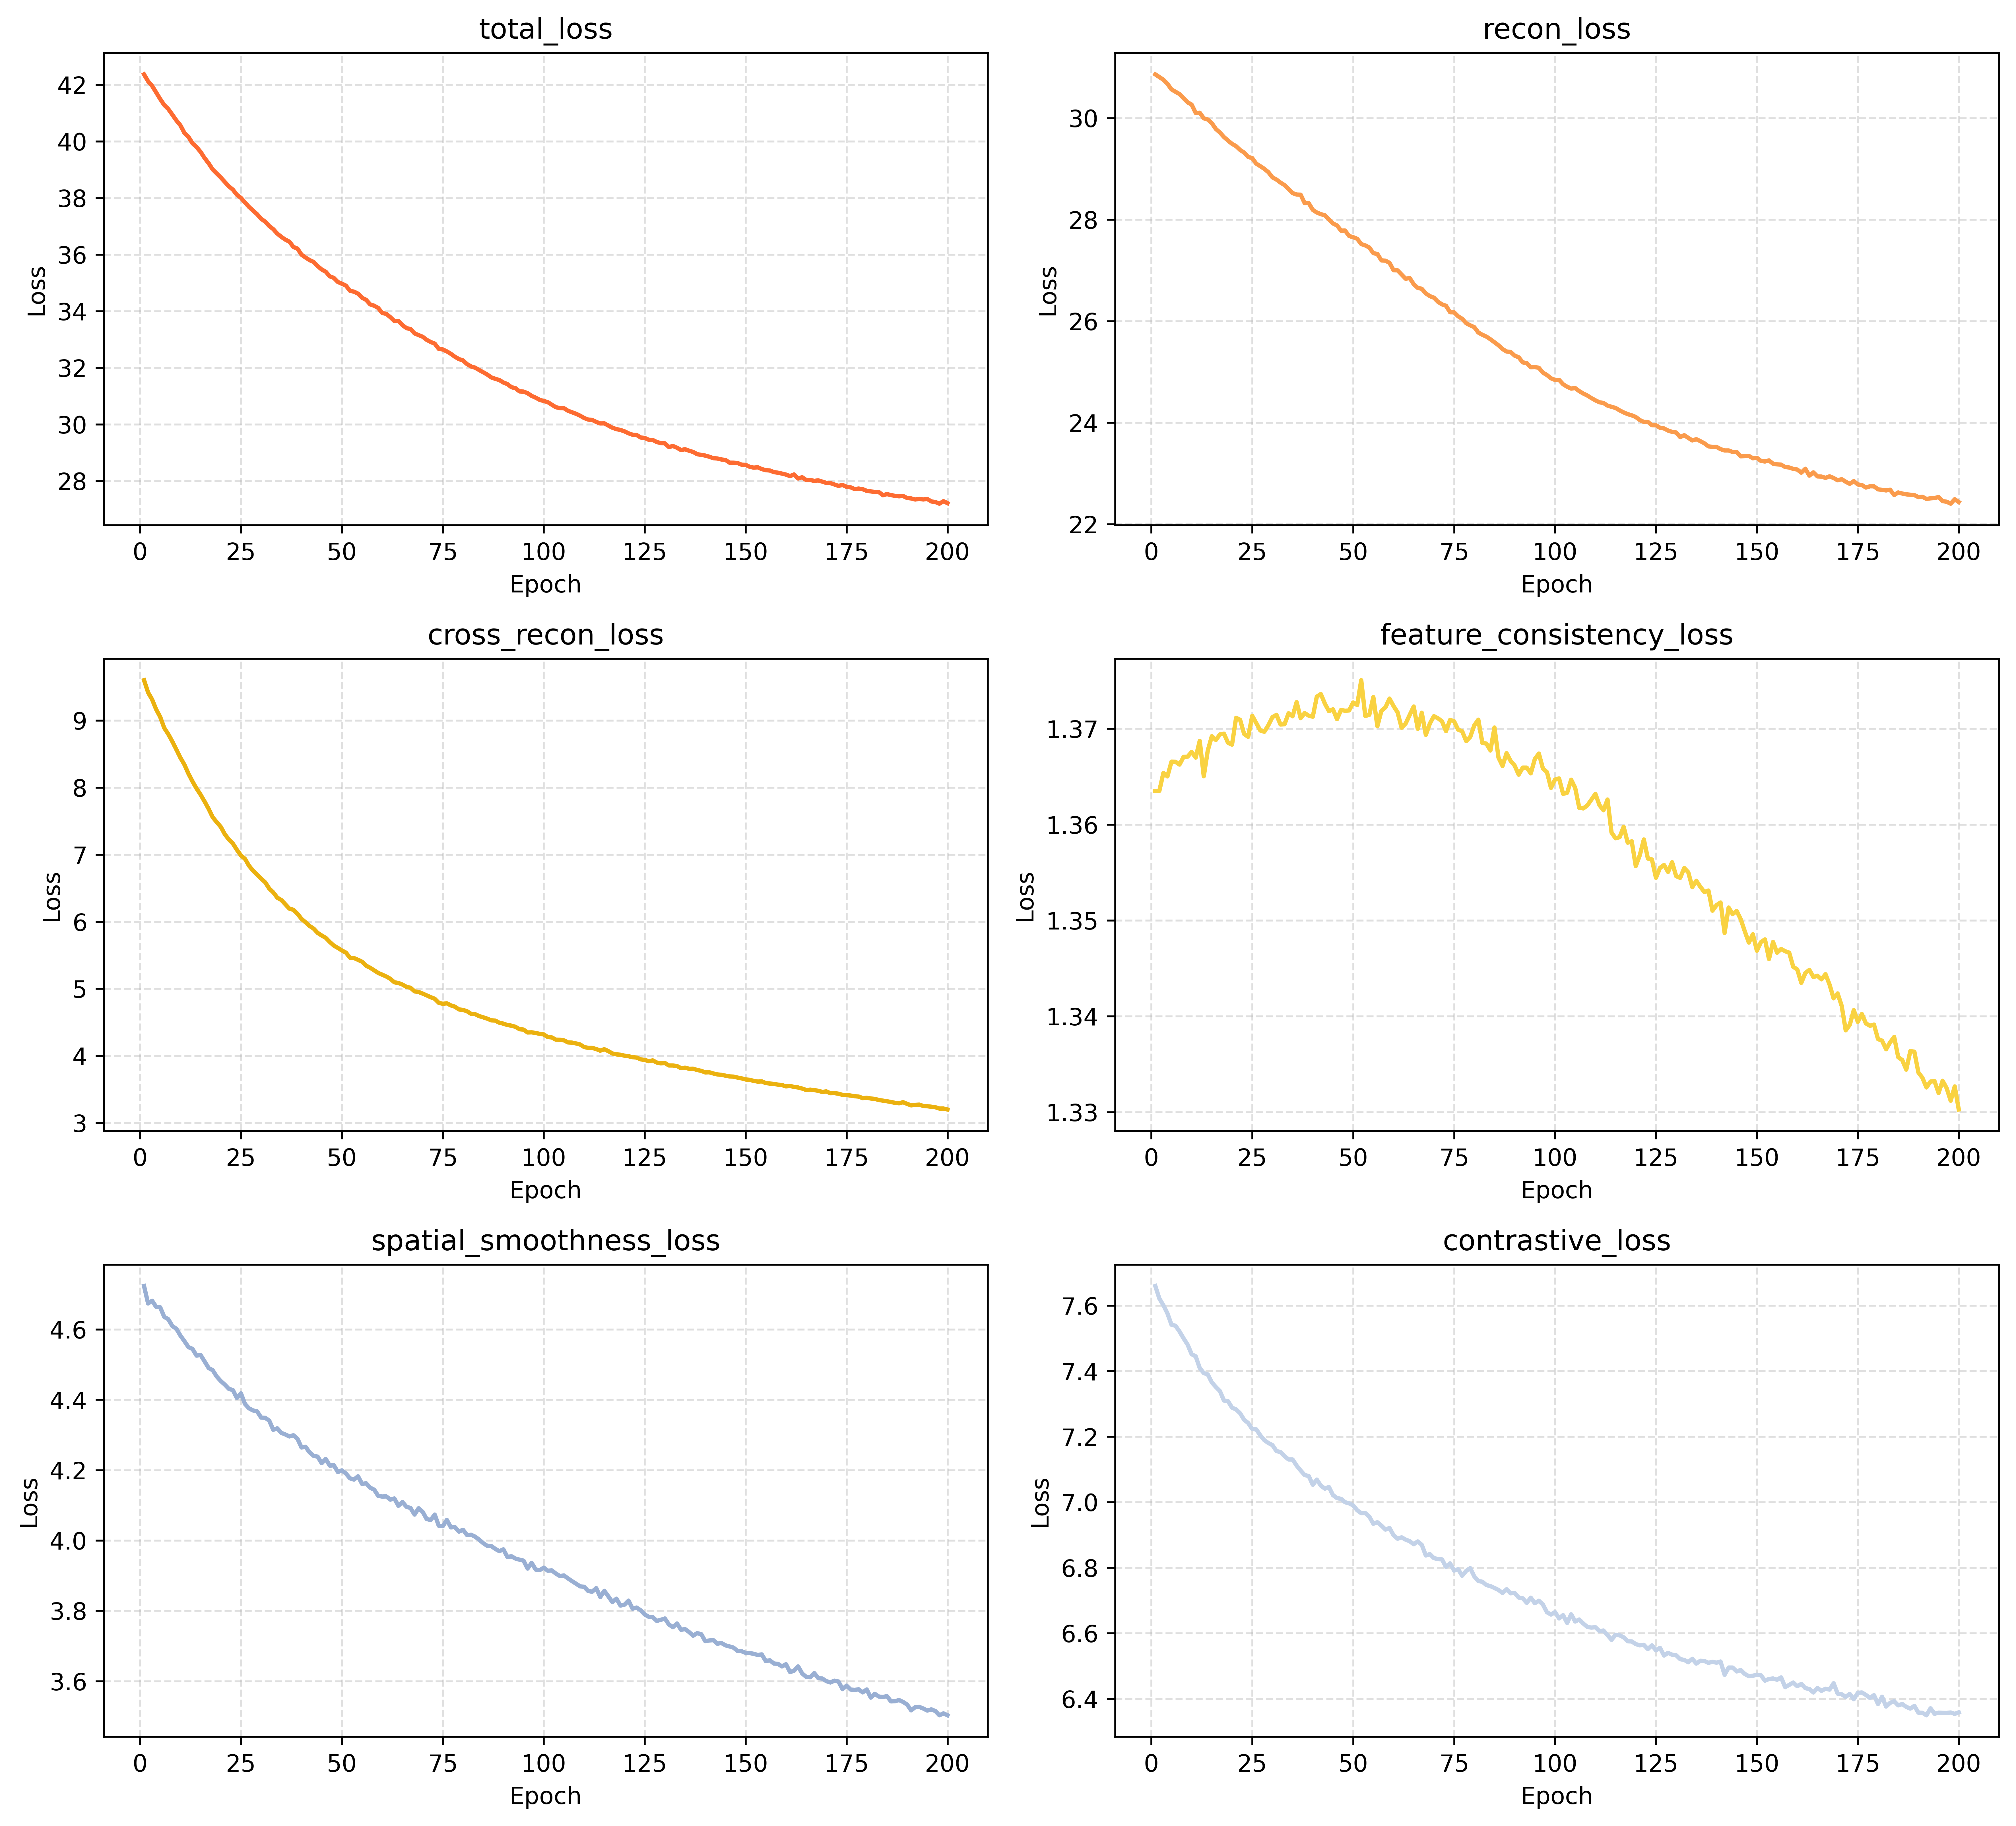

In [20]:
import math
import matplotlib.pyplot as plt

loss_history = output['loss_history']
loss_components = output.get('loss_components_history', {})
epochs = range(1, len(loss_history) + 1)

colors = [
    "#fd6b31",
    "#fa9b4c",
    "#ebb10f",
    "#f9d241",
    "#99afd3",
    "#c3d2e8"
]

all_loss_series = {'total_loss': loss_history, **loss_components}
n_plots = len(all_loss_series)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.6 * n_rows), dpi=600)
axes = np.atleast_1d(axes).ravel()

for ax, (loss_name, values), color in zip(axes, all_loss_series.items(), colors):
    ax.plot(epochs, values, color=color, linewidth=1.8)
    ax.set_title(loss_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, linestyle='--', alpha=0.4)

for ax in axes[n_plots:]:
    ax.axis('off')

fig.tight_layout()
plt.show()

In [6]:
adata = adata_omics1.copy()
attach_obsm_from_dict(
    adata,
    output,
    keys=[
        'emb_latent_omics1',
        'emb_latent_omics2',
        'emb_latent_omics3',
        'STARMap',
        'alpha',
        'alpha_omics1',
        'alpha_omics2',
        'alpha_omics3',
    ],
)
adata.write_h5ad('STARMap_Human_Lymph_Node.h5ad')

In [7]:
key = 'STARMap'
truth_key = 'ground_truth'
n_clusters = 6
method = 'mclust'

cluster_eval = run_embedding_clustering_evaluation(
    adata,
    embedding_key=key,
    label_path=ground_truth_path,
    n_clusters=n_clusters,
    method=method,
    truth_key=truth_key,
    pca_n_comps=30,
    random_seed=random_seed,
    pred_key=key,
)

scores_mclust = cluster_eval['scores']
labels_true = cluster_eval['labels_true']
label_order = cluster_eval['label_order']
confusion_mclust = cluster_eval['confusion']

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


In [8]:
print(pd.Series(scores_mclust, name='mclust_global').round(4).to_string())

ARI                   0.3433
NMI                   0.4281
AMI                   0.4257
Homogeneity Score     0.4076
Completeness Score    0.4508
V-Measure             0.4281


d:\Anaconda\envs\spatialglue\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


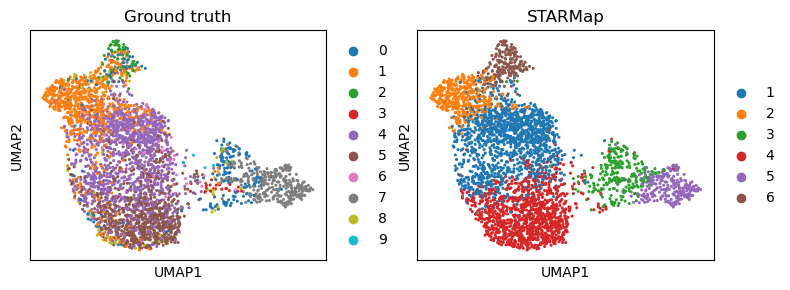

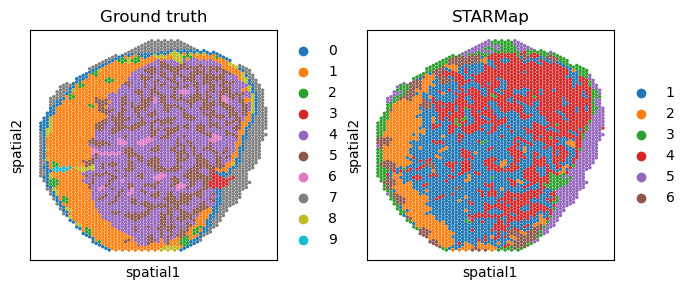

(<Figure size 700x300 with 2 Axes>,
 array([<Axes: title={'center': 'Ground truth'}, xlabel='spatial1', ylabel='spatial2'>,
        <Axes: title={'center': 'STARMap'}, xlabel='spatial1', ylabel='spatial2'>],
       dtype=object))

In [9]:
plot_umap_ground_truth_vs_prediction(
    adata,
    pred_key=key,
    truth_key='ground_truth',
    use_rep='STARMap',
    n_neighbors=10,
    figsize=(8, 3),
    point_size=20,
    pred_title='STARMap',
)

plot_spatial_cluster_comparison(
    adata,
    pred_key=key,
    truth_key='ground_truth',
    pred_title='STARMap',
)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_28228\2380600732.py:23: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=float(res), key_added='__tmp_leiden__', random_state=random_seed)


ARI                   0.1591
NMI                   0.3395
AMI                   0.3330
Homogeneity Score     0.4422
Completeness Score    0.2755
V-Measure             0.3395
best resolution=1.78, n_clusters=17


,truth_label,truth_count,truth_fraction,best_cluster,cluster_count,overlap_count,overlap_ratio_in_truth,precision,recall,f1,mcc
0,3,23,0.006602,14,101,18,0.782609,0.178218,0.782609,0.290323,0.366169
1,6,57,0.016361,6,210,14,0.245614,0.066667,0.245614,0.104869,0.100433
2,2,60,0.017222,5,245,59,0.983333,0.240816,0.983333,0.386885,0.472688
3,8,74,0.021240,12,144,16,0.216216,0.111111,0.216216,0.146789,0.129424


Rare label 3: n=23, frac=0.66%, best_cluster=14, F1=0.290, MCC=0.366


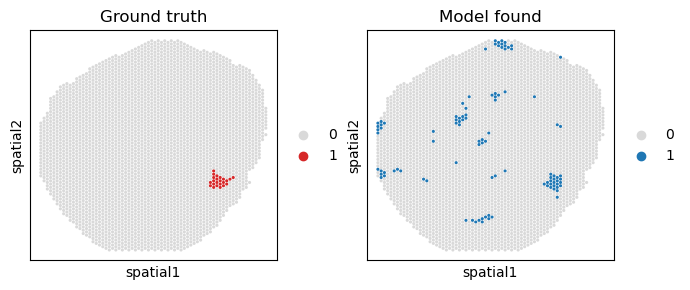

Rare label 6: n=57, frac=1.64%, best_cluster=6, F1=0.105, MCC=0.100


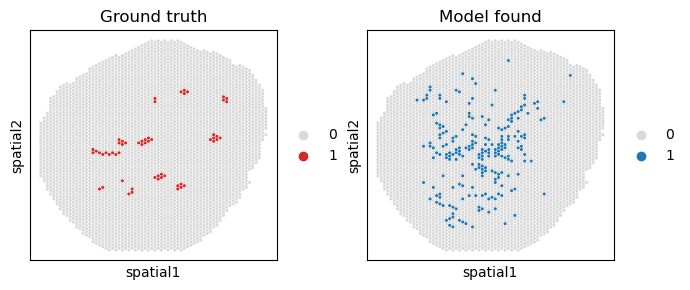

Rare label 2: n=60, frac=1.72%, best_cluster=5, F1=0.387, MCC=0.473


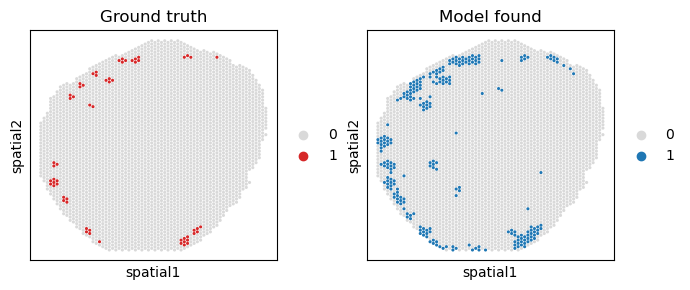

Rare label 8: n=74, frac=2.12%, best_cluster=12, F1=0.147, MCC=0.129


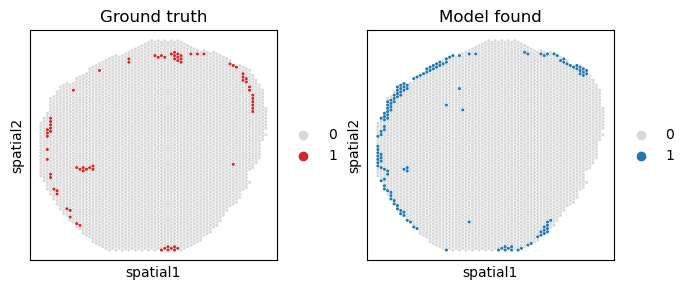

In [10]:
from sklearn.preprocessing import StandardScaler, normalize
from STARMap.utils import add_ground_truth_labels, summarize_best_matching_clusters, plot_rare_truth_vs_best_cluster_panels, evaluate_clustering

rare_key = f"{key}_leiden_cosine_k12_17"

add_ground_truth_labels(adata, ground_truth_path, label_key=truth_key)

X = np.asarray(adata.obsm[key], dtype=np.float64)
adata.obsm[f"{key}_z"] = StandardScaler().fit_transform(X)
adata.obsm[f"{key}_z_l2"] = normalize(adata.obsm[f"{key}_z"], norm='l2')

sc.pp.neighbors(
    adata,
    use_rep=f"{key}_z_l2",
    n_neighbors=12,
    metric='cosine',
)

best_res = None
best_gap = np.inf
target_clusters = 17
for res in np.arange(0.20, 3.01, 0.02):
    sc.tl.leiden(adata, resolution=float(res), key_added='__tmp_leiden__', random_state=random_seed)
    n_found = adata.obs['__tmp_leiden__'].nunique()
    gap = abs(n_found - target_clusters)
    if gap < best_gap:
        best_gap = gap
        best_res = float(res)
    if n_found == target_clusters:
        break

del adata.obs['__tmp_leiden__']
sc.tl.leiden(adata, resolution=best_res, key_added=rare_key, random_state=random_seed)

scores_leiden = evaluate_clustering(adata, pred_key=rare_key, truth_key=truth_key, verbose=False)
print(pd.Series(scores_leiden, name='leiden_cosine_k12_global').round(4).to_string())
print(f"best resolution={best_res:.2f}, n_clusters={adata.obs[rare_key].nunique()}")

_, rare_summary, _ = summarize_best_matching_clusters(
    adata,
    pred_key=rare_key,
    truth_key=truth_key,
    selection_metric='f1',
    exclude_truth_labels=['9'],
    rare_fraction_threshold=0.05,
)

if not rare_summary.empty:
    display(rare_summary)
    _ = plot_rare_truth_vs_best_cluster_panels(
        adata,
        rare_summary,
        label_key=truth_key,
        pred_key=rare_key,
        basis='spatial',
        figsize=(7, 3),
        spatial_point_size=20,
    )